In [119]:
from transformers import GPT2Model, GPT2Tokenizer
import torch

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

model = GPT2Model.from_pretrained(
    "gpt2",
    output_attentions=True,
    output_hidden_states=True
)

model.eval()

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 148/148 [00:00<00:00, 5317.89it/s]


GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
)

In [176]:
text = """
Augusta National rewards golfers who understand strategy rather than simply hitting the ball far. The course demands careful decisions because every hole presents unique challenges involving wind, slopes, hazards, and precise shot placement. Successful players study the course, adapt their approach, and use experience to navigate difficult situations throughout the tournament."""

inputs = tokenizer(
    text,
    return_tensors="pt"
)

print(inputs.input_ids.shape)

torch.Size([1, 63])


In [177]:
with torch.no_grad():
    outputs = model(**inputs)

In [125]:
def attention_to_delta(a, head_dim=64):

    log_a = torch.log(a + 1e-12)

    delta = -head_dim**0.5 * (
        log_a - log_a.max()
    )

    return delta

def compute_lambda_from_attention(a):

    Delta = attention_to_delta(a)

    Delta = Delta / (Delta.std()+1e-12)

    ts = torch.linspace(
        0.05,
        Delta.max(),
        100
    )

    vals=[]

    for t in ts:

        N=(Delta <= t).sum()

        if N > 1:
            vals.append(
                torch.log(N.float())/t
            )

    return torch.stack(vals).max()

In [133]:
def attention_entropy(a):
    return (
        -(a * torch.log(a + 1e-12)).sum()
    ).item()


def attention_to_delta(a, head_dim=64):
    """
    Recover relative energy gaps from softmax.
    
    Delta_j = E_j - E_min
    """
    
    log_a = torch.log(a + 1e-12)

    Delta = -head_dim**0.5 * (
        log_a - log_a.max()
    )

    return Delta


def compute_lambda(Delta):

    # normalize energy scale
    Delta = Delta / (Delta.std() + 1e-12)

    ts = torch.linspace(
        0.05,
        Delta.max(),
        100
    )

    values = []

    for t in ts:

        N = (Delta <= t).sum()

        if N > 1:
            values.append(
                torch.log(N.float()) / t
            )

    if len(values) == 0:
        return 0

    return torch.stack(values).max().item()

In [178]:
layer = 0
head = 0

A = outputs.attentions[layer][0, head]

entropies = []
lambdas = []

seq_len = A.shape[0]


for i in range(seq_len):

    # causal attention
    a = A[i,:i+1]

    if len(a) > 2:

        Delta = attention_to_delta(a)

        entropies.append(
            attention_entropy(a)
        )

        lambdas.append(
            compute_lambda(Delta)
        )


print("Entropy:", sum(entropies)/len(entropies))
print("Lambda:", sum(lambdas)/len(lambdas))

Entropy: 2.9803381122526575
Lambda: 3.450341793357349


In [179]:
import pandas as pd


results = []


for layer in range(len(outputs.attentions)):

    A_layer = outputs.attentions[layer]

    num_heads = A_layer.shape[1]

    for head in range(num_heads):

        A = A_layer[0,head]

        entropies = []
        lambdas = []

        for i in range(A.shape[0]):

            a = A[i,:i+1]

            if len(a)>2:

                Delta = attention_to_delta(a)

                entropies.append(
                    attention_entropy(a)
                )

                lambdas.append(
                    compute_lambda(Delta)
                )

        results.append({
            "layer": layer,
            "head": head,
            "entropy": sum(entropies)/len(entropies),
            "lambda": sum(lambdas)/len(lambdas)
        })


df = pd.DataFrame(results)

df.head()

,layer,head,entropy,lambda
0,0,0,2.980338,3.450342
1,0,1,0.258417,1.608358
2,0,2,2.998318,3.138541
3,0,3,0.381353,1.762622
4,0,4,1.251924,1.709785


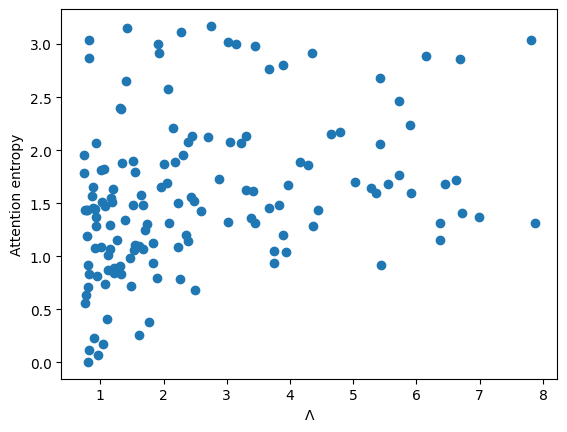

In [180]:
plt.scatter(
    df["lambda"],
    df["entropy"]
)

plt.xlabel(r"$\Lambda$")
plt.ylabel("Attention entropy")

plt.show()

In [218]:
import numpy as np
from scipy.optimize import minimize_scalar


def fit_beta(a):

    Delta = attention_to_delta(a)
    return Delta.std()

In [219]:
results = []


for layer in range(len(outputs.attentions)):

    A_layer = outputs.attentions[layer]

    for head in range(A_layer.shape[1]):

        A = A_layer[0,head]

        entropies = []
        lambdas = []
        betas = []

        for i in range(A.shape[0]):

            a = A[i,:i+1]

            if len(a)>2:

                Delta = attention_to_delta(a)

                entropies.append(
                    attention_entropy(a)
                )

                lambdas.append(
                    compute_lambda(Delta)
                )

                betas.append(
                    fit_beta(a)
                )


        results.append({
            "layer": layer,
            "head": head,
            "entropy": np.mean(entropies),
            "lambda": np.mean(lambdas),
            "beta": np.mean(betas)
        })


df = pd.DataFrame(results)

KeyboardInterrupt: 

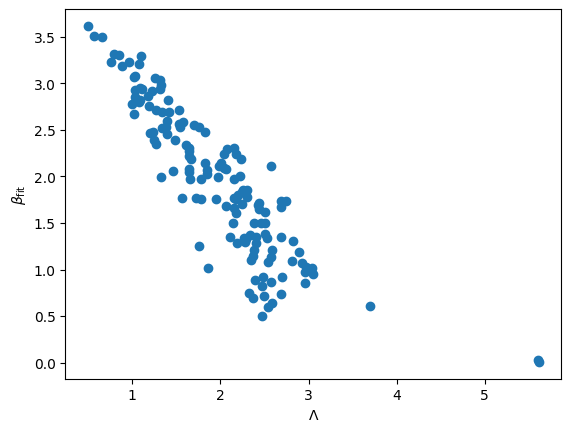

In [212]:
plt.scatter(
    df["beta"],
    df["entropy"]
)

plt.xlabel(r"$\Lambda$")
plt.ylabel(r"$\beta_{\mathrm{fit}}$")

plt.show()

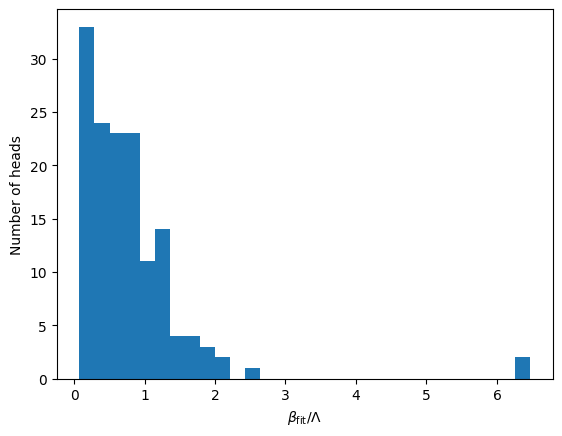

In [207]:
df["beta_lambda_ratio"] = (
    df["beta"] /
    df["lambda"]
)

plt.hist(
    df["beta_lambda_ratio"],
    bins=30
)

plt.xlabel(r"$\beta_{\mathrm{fit}}/\Lambda$")
plt.ylabel("Number of heads")

plt.show()

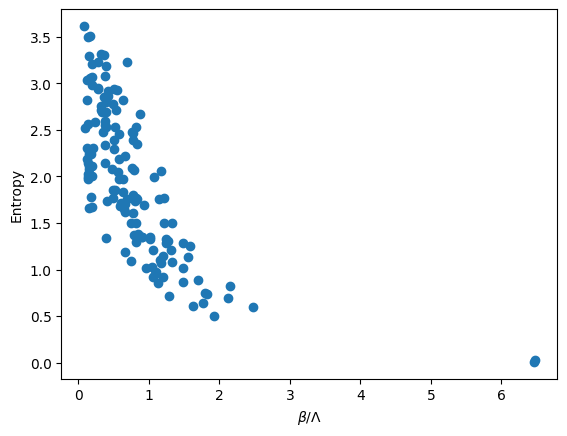

In [208]:
plt.scatter(
    df["beta_lambda_ratio"],
    df["entropy"]
)

plt.xlabel(r"$\beta/\Lambda$")
plt.ylabel("Entropy")

plt.show()

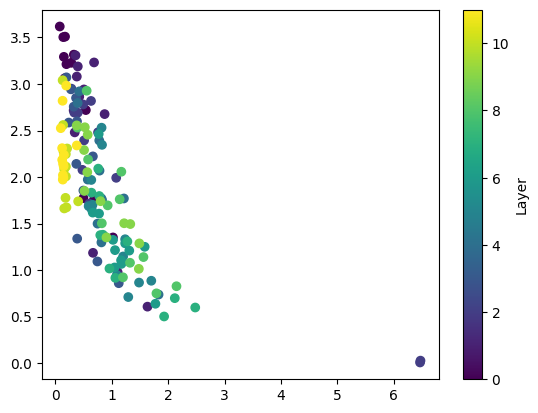

In [209]:
plt.scatter(
    df["beta_lambda_ratio"],
    df["entropy"],
    c=df["layer"]
)
plt.colorbar(label="Layer")
plt.show()

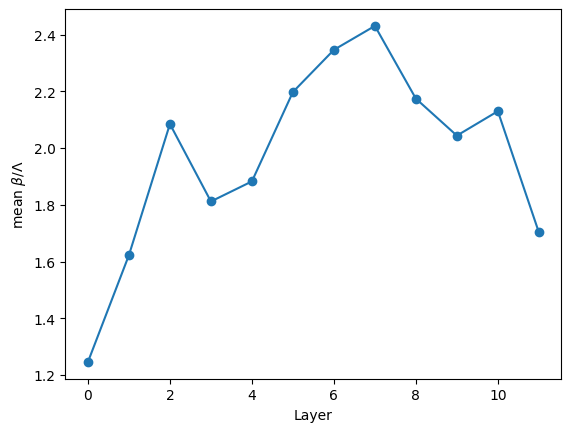

In [217]:
layer_ratio = (
    df
    .groupby("layer")["beta"]
    .mean()
)

plt.plot(
    layer_ratio.index,
    layer_ratio.values,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel(r"mean $\beta/\Lambda$")
plt.show()

In [233]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model = BertModel.from_pretrained(
    "bert-base-uncased",
    output_attentions=True
)

model.eval()

text = """
Augusta National Golf Club is one of the most famous golf courses in the world.
Its fast greens, dramatic elevation changes, and strategic design reward precision,
patience, and careful decision making throughout every round.
"""

inputs = tokenizer(
    text,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = model(**inputs)

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 5458.90it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [220]:
results = []


for layer in range(len(outputs.attentions)):

    A_layer = outputs.attentions[layer]

    for head in range(A_layer.shape[1]):

        A = A_layer[0,head]

        entropies = []
        lambdas = []
        betas = []

        for i in range(A.shape[0]):

            a = A[i, :]

            if len(a)>2:

                Delta = attention_to_delta(a)

                entropies.append(
                    attention_entropy(a)
                )

                lambdas.append(
                    compute_lambda(Delta)
                )

                betas.append(
                    fit_beta(a)
                )


        results.append({
            "layer": layer,
            "head": head,
            "entropy": np.mean(entropies),
            "lambda": np.mean(lambdas),
            "beta": np.mean(betas)
        })


df = pd.DataFrame(results)

In [244]:
def plot_all_heads_delta_landscape(
    outputs,
    layer=0,
    query_idx=-1,
    attention_mask=None,
    top_k=50
):

    A_layer = outputs.attentions[layer][0]
    # shape: (heads, query_tokens, key_tokens)

    num_heads = A_layer.shape[0]

    plt.figure(figsize=(8,6))

    for h in range(num_heads):

        A = A_layer[h, query_idx]

        # remove padding
        if attention_mask is not None:
            A = A[attention_mask.bool()]

        # invert softmax
        scores = torch.log(A + 1e-12)

        # energy gaps
        delta = scores.max() - scores

        # sort gaps
        delta = torch.sort(delta).values

        if top_k is not None:
            delta = delta[:top_k]

        plt.plot(
            delta.detach().cpu().numpy(),
            alpha=0.6,
            label=f"Head {h}"
        )

    plt.xlabel("rank")
    plt.ylabel(r"$\Delta$")
    plt.title(f"Layer {layer}: all head score landscapes")

    plt.show()

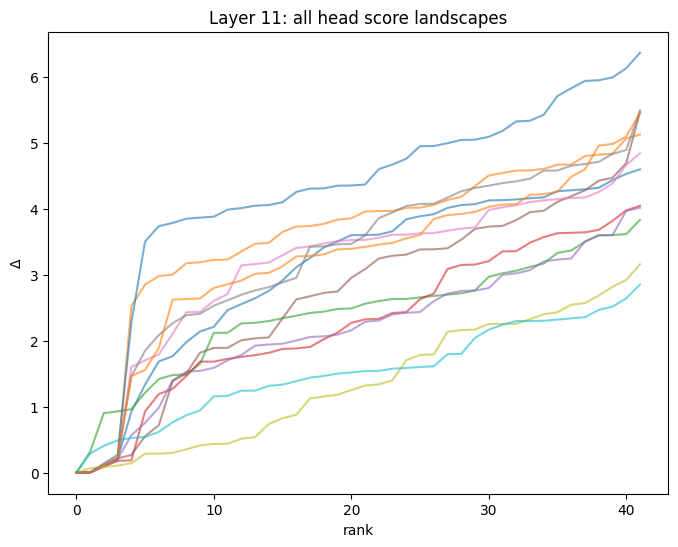

In [245]:
plot_all_heads_delta_landscape(
    outputs,
    layer=11,
    query_idx=-1,
    attention_mask=inputs["attention_mask"][0]
)

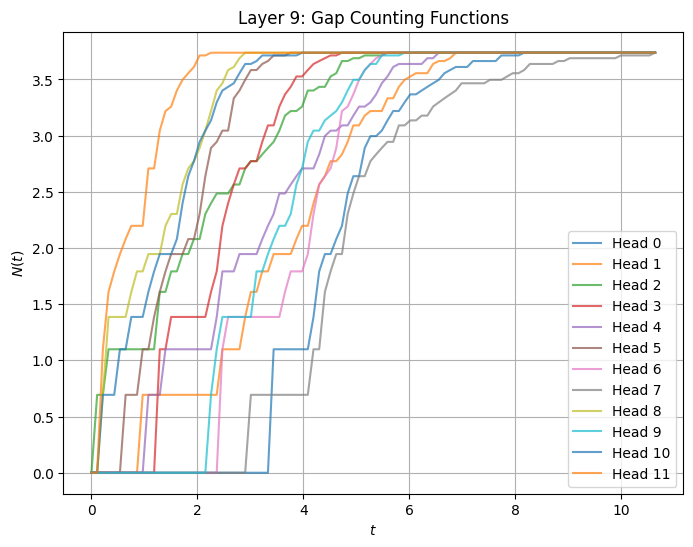

In [264]:
def plot_all_heads_gap_counting(
    outputs,
    layer=0,
    query_idx=-1,
    attention_mask=None,
    num_points=100
):

    A_layer = outputs.attentions[layer][0]
    # (heads, query_tokens, key_tokens)

    num_heads = A_layer.shape[0]

    # collect all deltas first so t range is shared
    all_deltas = []

    for h in range(num_heads):

        A = A_layer[h, query_idx]

        if attention_mask is not None:
            A = A[attention_mask.bool()]

        scores = torch.log(A + 1e-12)

        delta = scores.max() - scores

        all_deltas.append(delta)

    t_max = max(
        d.max().item()
        for d in all_deltas
    )

    t = torch.linspace(0, t_max, num_points)

    plt.figure(figsize=(8,6))

    for h, delta in enumerate(all_deltas):

        N = torch.tensor([
            (delta <= ti).sum()
            for ti in t
        ])

        plt.plot(
            t.numpy(),
            torch.log(N).numpy(),
            alpha=0.7,
            label=f"Head {h}"
        )

    plt.xlabel(r"$t$")
    plt.ylabel(r"$N(t)$")
    plt.title(f"Layer {layer}: Gap Counting Functions")

    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_all_heads_gap_counting(
    outputs,
    layer=9,
    query_idx=-1,
    attention_mask=inputs["attention_mask"][0]
)

In [258]:
np.exp(-0)

np.float64(1.0)

In [259]:
np.exp(-4)

np.float64(0.01831563888873418)

In [266]:
def analyze_layer_entropy(outputs, attention_mask=None):
    """
    Computes mean attention entropy per layer.

    outputs.attentions:
        tuple(num_layers) of
        (batch, heads, query_len, key_len)

    attention_mask:
        (batch, seq_len), 1 = valid token, 0 = padding
    """

    layer_entropy = []

    for layer_attn in outputs.attentions:

        # remove batch dimension
        A = layer_attn[0]
        # shape: (heads, query, key)

        num_heads, seq_len, _ = A.shape

        entropies = []

        for h in range(num_heads):

            head = A[h]

            for i in range(seq_len):

                probs = head[i]

                # remove padding keys
                if attention_mask is not None:
                    mask = attention_mask.bool()
                    probs = probs[mask]

                H = -(probs * torch.log(probs + 1e-12)).sum()

                entropies.append(H.item())

        layer_entropy.append(
            sum(entropies) / len(entropies)
        )

    return layer_entropy

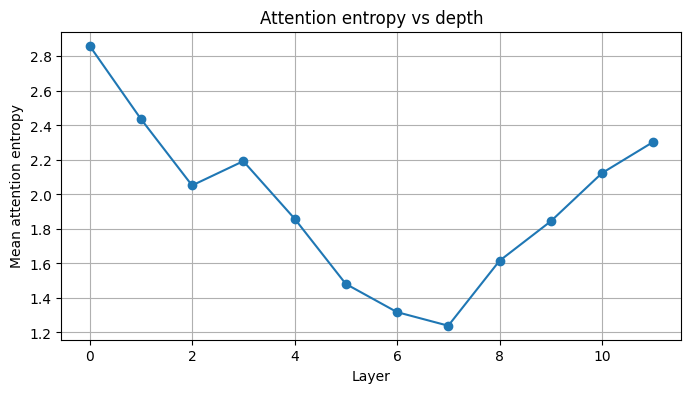

In [268]:
entropy = analyze_layer_entropy(
    outputs,
    attention_mask=inputs["attention_mask"][0]
)

plt.figure(figsize=(8,4))

plt.plot(
    range(len(entropy)),
    entropy,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("Mean attention entropy")
plt.title("Attention entropy vs depth")

plt.grid(True)
plt.show()

In [269]:
def analyze_layer_entropies(outputs, attention_mask=None):
    """
    Computes all attention entropies per layer.

    Returns
    -------
    layer_entropies : list[list[float]]
        layer_entropies[layer] is a list containing the entropy of every
        (head, query position) pair in that layer.

    outputs.attentions:
        tuple(num_layers) of tensors with shape
        (batch, heads, query_len, key_len)

    attention_mask:
        (seq_len,) or (batch, seq_len), where 1 = valid token, 0 = padding
    """

    layer_entropies = []

    if attention_mask is not None:
        if attention_mask.ndim == 2:
            attention_mask = attention_mask[0]
        attention_mask = attention_mask.bool()

    for layer_attn in outputs.attentions:

        # (heads, query, key)
        A = layer_attn[0]

        num_heads, seq_len, _ = A.shape

        entropies = []

        for h in range(num_heads):
            head = A[h]

            for i in range(seq_len):
                probs = head[i]

                if attention_mask is not None:
                    probs = probs[attention_mask]

                H = -(probs * torch.log(probs + 1e-12)).sum()

                entropies.append(H.item())

        layer_entropies.append(entropies)

    return layer_entropies

In [274]:
def analyze_head_entropy(outputs, attention_mask=None):
    """
    Returns:
        entropy[layer][head]
    = average entropy over query tokens for each head.
    """

    entropy_matrix = []

    for layer_attn in outputs.attentions:

        # Remove batch dimension
        A = layer_attn[0]
        # Shape: (heads, query_len, key_len)

        num_heads, seq_len, _ = A.shape

        layer_entropy = []

        for h in range(num_heads):

            head_entropies = []

            for i in range(seq_len):

                probs = A[h, i]

                # Remove padding tokens (BERT)
                if attention_mask is not None:
                    probs = probs[attention_mask.bool()]

                H = -(probs * torch.log(probs + 1e-12)).sum()

                head_entropies.append(H.item())

            layer_entropy.append(sum(head_entropies) / len(head_entropies))

        entropy_matrix.append(layer_entropy)

    return torch.tensor(entropy_matrix)

In [275]:
entropy = analyze_head_entropy(
    outputs,
    attention_mask=inputs["attention_mask"][0]
)

print(entropy.shape)

torch.Size([12, 12])


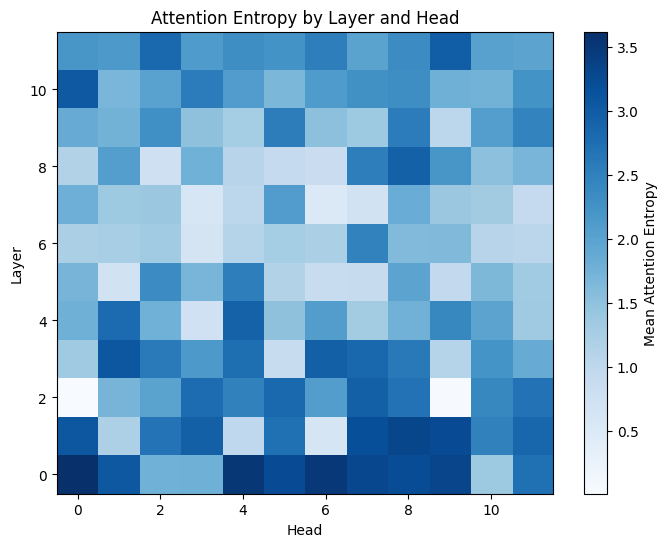

In [279]:

plt.figure(figsize=(8,6))

plt.imshow(entropy, aspect="auto", origin="lower", cmap='Blues')
plt.colorbar(label="Mean Attention Entropy")

plt.xlabel("Head")
plt.ylabel("Layer")
plt.title("Attention Entropy by Layer and Head")

plt.show()